# **Instagram: Improving Engagement Quality & Retention**

Instagram is one of the world’s largest social platforms, used daily for entertainment, discovery, and communication through formats like Feed, Reels, Stories, Explore, and DMs.

As the platform grows, leadership is shifting focus from simply increasing time spent to improving Engagement Quality — ensuring user activity is healthy, consistent, and sustainable rather than driven by passive scrolling, notification overload, or low-intent interactions.

Poor engagement quality can lead to lower long-term retention, weaker creator engagement, higher trust and safety risks, and reduced monetization performance. To address this, Instagram is leveraging user lifestyle and behavioral data to better understand and improve how meaningful engagement happens on the platform.


## Objective

The goal of this project is to analyze user behavior data and identify patterns that influence Engagement Quality Efficiency (EQE).

EQE = Meaningful Engagement ÷ Attention (Time Spent)

This project aims to:

Break down EQE across demographics, platform usage, content preferences, and trust settings

Identify high-EQE users (healthy engagement) vs low-EQE users (passive scrolling)

Detect dormancy and churn risk segments

Explore how lifestyle factors (sleep, stress, exercise) relate to engagement quality

Provide data-driven recommendations to improve meaningful engagement while reducing unhealthy usage patterns

## Business Impact

Improving EQE can increase long-term retention, strengthen the creator ecosystem, improve ad performance, and build healthier user behavior. This helps Instagram grow sustainably while improving user satisfaction and platform trust.

# **Dataset Overview**

### **Dataset Overview**

- **Dataset Name**: Instagram Engagement & Lifestyle Dataset
- **Number of Rows**: 1,547,896  
- **Number of Columns**: 58  
- **Description**: This dataset captures detailed user-level metrics related to Instagram activity, engagement behavior, content preferences, notification interactions, and lifestyle indicators. Each row represents a specific user’s behavioral and engagement metrics over a defined time period, enabling analysis of engagement quality, retention patterns, and user well-being signals.

# **Analysis & Visualisation !**

# **Importing and Cleaning Data**

### Importing Necessary Libraries and  Loading the Dataset from google drive

In [ ]:
# Step 1: Install gdown
!pip install gdown

# Step 2: Import below libraries
import gdown
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Step 3: Set the file ID and create a download URL
# E.g. for Instagram.csv the URL is  --https://drive.google.com/file/d/1iFlv5PjnezdaCcTzWsjAX-Ck9kMCBMMK/view?usp=sharing Anything beween d/ and /view is the file ID

file_id = "16nG7VaTdxL1xpi3ZuYrUf5lTV7bvTyxP"
download_url = f"https://drive.google.com/uc?id={file_id}"

# Step 4: Set the output file name
output_file = "instagram_dataset.csv"

# Step 5: Download the file
gdown.download(download_url, output_file, quiet=False)

# Step 6: Load the CSV file into a Pandas DataFrame (change name according to your choice)
data = pd.read_csv(output_file)

Downloading...
From (original): https://drive.google.com/uc?id=16nG7VaTdxL1xpi3ZuYrUf5lTV7bvTyxP
From (redirected): https://drive.google.com/uc?id=16nG7VaTdxL1xpi3ZuYrUf5lTV7bvTyxP&confirm=t&uuid=30b4b671-5af1-4594-8848-9f69685d5c31
To: /content/instagram_dataset.csv
100%|██████████| 440M/440M [00:05<00:00, 86.6MB/s]


In [ ]:
data.shape

(1547896, 58)

- Dataset Size: 1.55 million users × 58 features capturing engagement, behavior and lifestyle.

In [ ]:
data.head(2)

,user_id,app_name,age,gender,country,urban_rural,income_level,employment_status,education_level,relationship_status,...,last_login_date,average_session_length_minutes,content_type_preference,preferred_content_theme,privacy_setting_level,two_factor_auth_enabled,biometric_login_used,linked_accounts_count,subscription_status,user_engagement_score
0,1,Instagram,51,Female,India,Rural,High,Retired,Bachelor’s,Single,...,2025-11-02,5.0,Mixed,Tech,Private,Yes,No,0,Free,7.83
1,2,Instagram,64,Female,United Kingdom,Urban,Middle,Full-time employed,Other,Divorced,...,2025-03-22,14.8,Photos,Fashion,Public,No,No,3,Free,1.43


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1547896 entries, 0 to 1547895
Data columns (total 58 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   user_id                         1547896 non-null  int64  
 1   app_name                        1547896 non-null  object 
 2   age                             1547896 non-null  int64  
 3   gender                          1547896 non-null  object 
 4   country                         1547896 non-null  object 
 5   urban_rural                     1547896 non-null  object 
 6   income_level                    1547896 non-null  object 
 7   employment_status               1547896 non-null  object 
 8   education_level                 1547896 non-null  object 
 9   relationship_status             1547896 non-null  object 
 10  has_children                    1547896 non-null  object 
 11  exercise_hours_per_week         1547896 non-null  float64
 12  

In [ ]:
data['last_login_date'] = pd.to_datetime(data['last_login_date'])
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1547896 entries, 0 to 1547895
Data columns (total 58 columns):
 #   Column                          Non-Null Count    Dtype         
---  ------                          --------------    -----         
 0   user_id                         1547896 non-null  int64         
 1   app_name                        1547896 non-null  object        
 2   age                             1547896 non-null  int64         
 3   gender                          1547896 non-null  object        
 4   country                         1547896 non-null  object        
 5   urban_rural                     1547896 non-null  object        
 6   income_level                    1547896 non-null  object        
 7   employment_status               1547896 non-null  object        
 8   education_level                 1547896 non-null  object        
 9   relationship_status             1547896 non-null  object        
 10  has_children                    1547896 no

- The last_login_date column was converted from object type to datetime format

### Cleaning

In [ ]:
data.duplicated().sum()

np.int64(0)

- No duplicate in dataset.

In [ ]:
data.isnull().sum()

,0
user_id,0
app_name,0
age,0
gender,0
country,0
urban_rural,0
income_level,0
employment_status,0
education_level,0
relationship_status,0


- No missing values in dataset.

### Outliers

In [ ]:
data.describe()

,user_id,age,exercise_hours_per_week,sleep_hours_per_night,perceived_stress_score,self_reported_happiness,body_mass_index,blood_pressure_systolic,blood_pressure_diastolic,daily_steps_count,...,time_on_messages_per_day,time_on_reels_per_day,followers_count,following_count,notification_response_rate,account_creation_year,last_login_date,average_session_length_minutes,linked_accounts_count,user_engagement_score
count,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,...,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1547896,1.547896e+06,1.547896e+06,1.547896e+06
mean,7.739485e+05,3.898544e+01,7.143480e+00,6.999384e+00,1.998774e+01,5.499804e+00,2.500084e+01,1.244917e+02,7.950007e+01,8.000105e+03,...,3.295203e+01,5.647662e+01,2.160543e+03,2.604942e+03,5.002404e-01,2.017501e+03,2025-07-04 01:16:13.479355648,2.050971e+01,1.975254e+00,1.644642e+00
min,1.000000e+00,1.300000e+01,0.000000e+00,3.000000e+00,0.000000e+00,1.000000e+00,1.500000e+01,9.000000e+01,6.000000e+01,7.566000e+03,...,1.000000e+00,1.000000e+00,1.000000e+01,2.000000e+01,0.000000e+00,2.010000e+03,2025-01-01 00:00:00,5.000000e+00,0.000000e+00,6.700000e-01
25%,3.869748e+05,2.600000e+01,4.000000e+00,6.300000e+00,1.000000e+01,3.000000e+00,2.230000e+01,1.070000e+02,7.000000e+01,7.940000e+03,...,1.600000e+01,2.900000e+01,5.430000e+02,6.630000e+02,2.500000e-01,2.013000e+03,2025-04-03 00:00:00,1.330000e+01,1.000000e+00,1.000000e+00
50%,7.739485e+05,3.900000e+01,6.600000e+00,7.000000e+00,2.000000e+01,5.000000e+00,2.500000e+01,1.240000e+02,7.900000e+01,8.000000e+03,...,3.100000e+01,5.400000e+01,1.154000e+03,1.519000e+03,5.000000e-01,2.017000e+03,2025-07-04 00:00:00,2.040000e+01,2.000000e+00,1.100000e+00
75%,1.160922e+06,5.200000e+01,9.700000e+00,7.700000e+00,3.000000e+01,8.000000e+00,2.770000e+01,1.420000e+02,9.000000e+01,8.060000e+03,...,4.700000e+01,8.000000e+01,2.459000e+03,3.451000e+03,7.500000e-01,2.022000e+03,2025-10-04 00:00:00,2.760000e+01,3.000000e+00,1.290000e+00
max,1.547896e+06,6.500000e+01,2.410000e+01,1.000000e+01,4.000000e+01,1.000000e+01,4.500000e+01,1.590000e+02,9.900000e+01,8.473000e+03,...,1.380000e+02,2.220000e+02,2.088110e+05,1.000000e+04,1.000000e+00,2.025000e+03,2026-01-04 00:00:00,5.200000e+01,5.000000e+00,1.867000e+01
std,4.468392e+05,1.529453e+01,3.994556e+00,1.097098e+00,1.183258e+01,2.871232e+00,3.976188e+00,2.020699e+01,1.154874e+01,8.939761e+01,...,2.144569e+01,3.534782e+01,3.402016e+03,2.751922e+03,2.887827e-01,4.611735e+00,NaN,8.697454e+00,1.352058e+00,1.812684e+00


In [ ]:
cols = [
    'likes_given_per_day',
    'comments_written_per_day',
    'dms_sent_per_week',
    'dms_received_per_week',
    'posts_created_per_week',
    'time_on_feed_per_day',
    'time_on_reels_per_day',
    'time_on_explore_per_day',
    'time_on_messages_per_day',
    'ads_viewed_per_day',
    'ads_clicked_per_day'
]


data[cols].describe()


,likes_given_per_day,comments_written_per_day,dms_sent_per_week,dms_received_per_week,posts_created_per_week,time_on_feed_per_day,time_on_reels_per_day,time_on_explore_per_day,time_on_messages_per_day,ads_viewed_per_day,ads_clicked_per_day
count,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06
mean,1.191122e+02,3.421294e+01,2.881592e+01,3.058328e+01,5.960338e+00,9.413037e+01,5.647662e+01,3.762037e+01,3.295203e+01,2.005123e+01,4.765017e+00
std,5.614637e+01,1.746649e+01,1.224658e+01,1.432850e+01,3.888248e+00,5.649837e+01,3.534782e+01,2.535788e+01,2.144569e+01,9.864529e+00,3.104442e+00
min,8.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,7.500000e+01,2.000000e+01,1.900000e+01,1.900000e+01,3.000000e+00,5.000000e+01,2.900000e+01,1.800000e+01,1.600000e+01,1.200000e+01,2.000000e+00
50%,1.180000e+02,3.300000e+01,2.800000e+01,3.000000e+01,5.000000e+00,9.200000e+01,5.400000e+01,3.400000e+01,3.100000e+01,1.900000e+01,4.000000e+00
75%,1.610000e+02,4.700000e+01,3.700000e+01,4.100000e+01,8.000000e+00,1.350000e+02,8.000000e+01,5.300000e+01,4.700000e+01,2.700000e+01,7.000000e+00
max,3.500000e+02,8.000000e+01,9.400000e+01,9.000000e+01,3.000000e+01,3.280000e+02,2.220000e+02,1.710000e+02,1.380000e+02,5.000000e+01,2.000000e+01


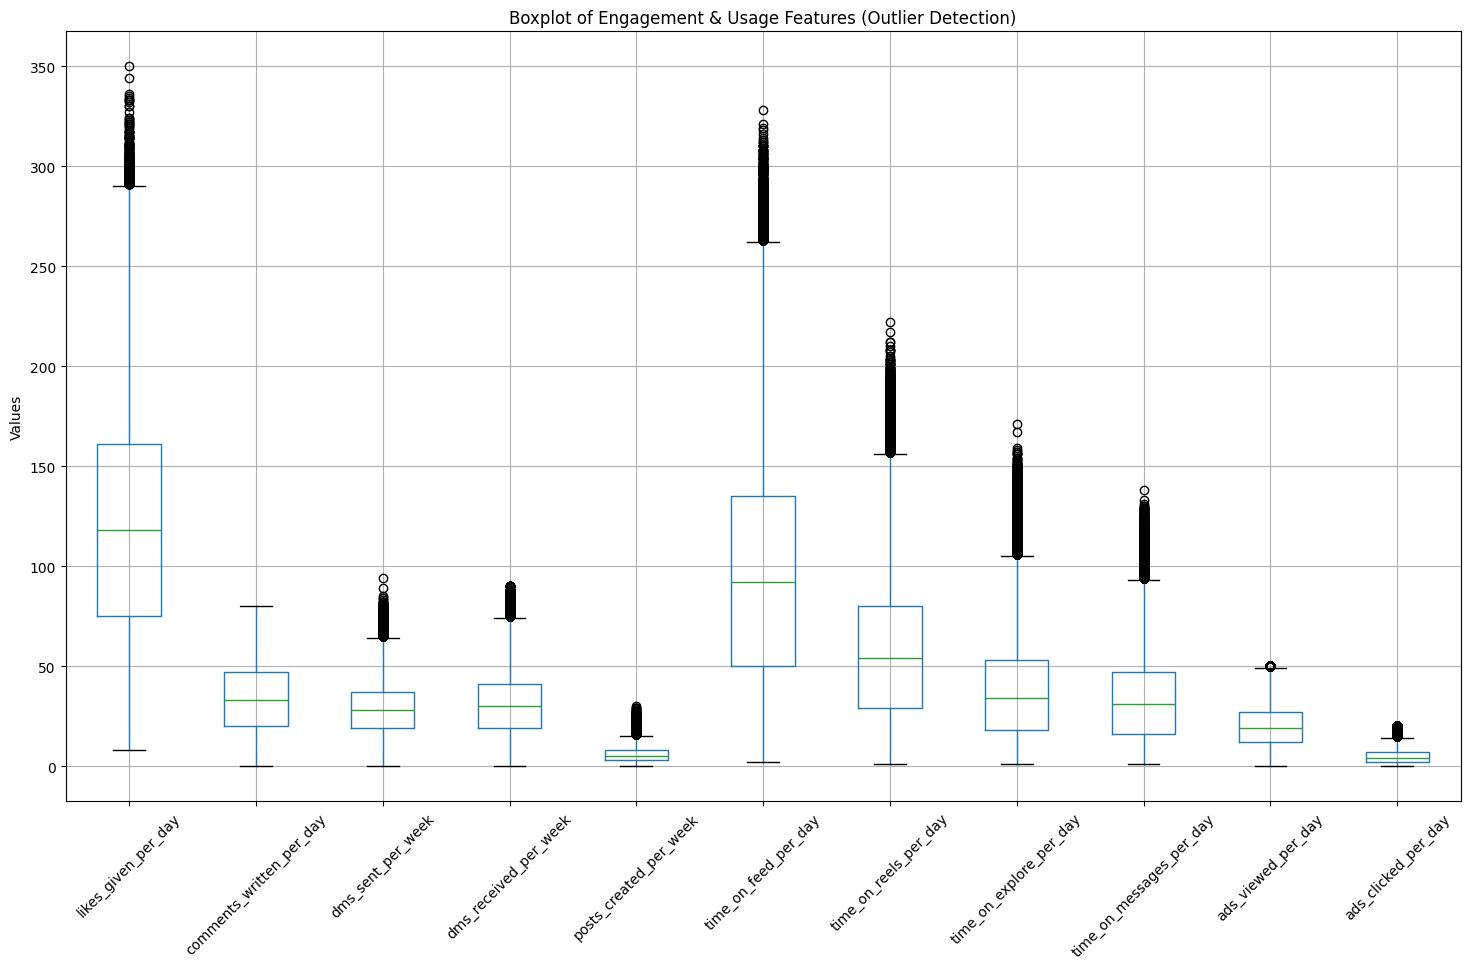

In [ ]:
plt.figure(figsize=(18,10))
data[cols].boxplot(rot=45)
plt.title("Boxplot of Engagement & Usage Features (Outlier Detection)")
plt.ylabel("Values")
plt.show()

In [ ]:
for col in cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    data[col] = data[col].clip(lower_limit, upper_limit)

In [ ]:
data[cols].describe()


,likes_given_per_day,comments_written_per_day,dms_sent_per_week,dms_received_per_week,posts_created_per_week,time_on_feed_per_day,time_on_reels_per_day,time_on_explore_per_day,time_on_messages_per_day,ads_viewed_per_day,ads_clicked_per_day
count,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06,1.547896e+06
mean,1.191095e+02,3.421294e+01,2.880661e+01,3.057881e+01,5.918504e+00,9.411888e+01,5.643597e+01,3.752322e+01,3.291032e+01,2.005014e+01,4.758408e+00
std,5.613769e+01,1.746649e+01,1.221726e+01,1.431392e+01,3.764551e+00,5.646193e+01,3.522233e+01,2.506512e+01,2.131589e+01,9.861266e+00,3.080929e+00
min,8.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,7.500000e+01,2.000000e+01,1.900000e+01,1.900000e+01,3.000000e+00,5.000000e+01,2.900000e+01,1.800000e+01,1.600000e+01,1.200000e+01,2.000000e+00
50%,1.180000e+02,3.300000e+01,2.800000e+01,3.000000e+01,5.000000e+00,9.200000e+01,5.400000e+01,3.400000e+01,3.100000e+01,1.900000e+01,4.000000e+00
75%,1.610000e+02,4.700000e+01,3.700000e+01,4.100000e+01,8.000000e+00,1.350000e+02,8.000000e+01,5.300000e+01,4.700000e+01,2.700000e+01,7.000000e+00
max,2.900000e+02,8.000000e+01,6.400000e+01,7.400000e+01,1.550000e+01,2.625000e+02,1.565000e+02,1.055000e+02,9.350000e+01,4.950000e+01,1.450000e+01


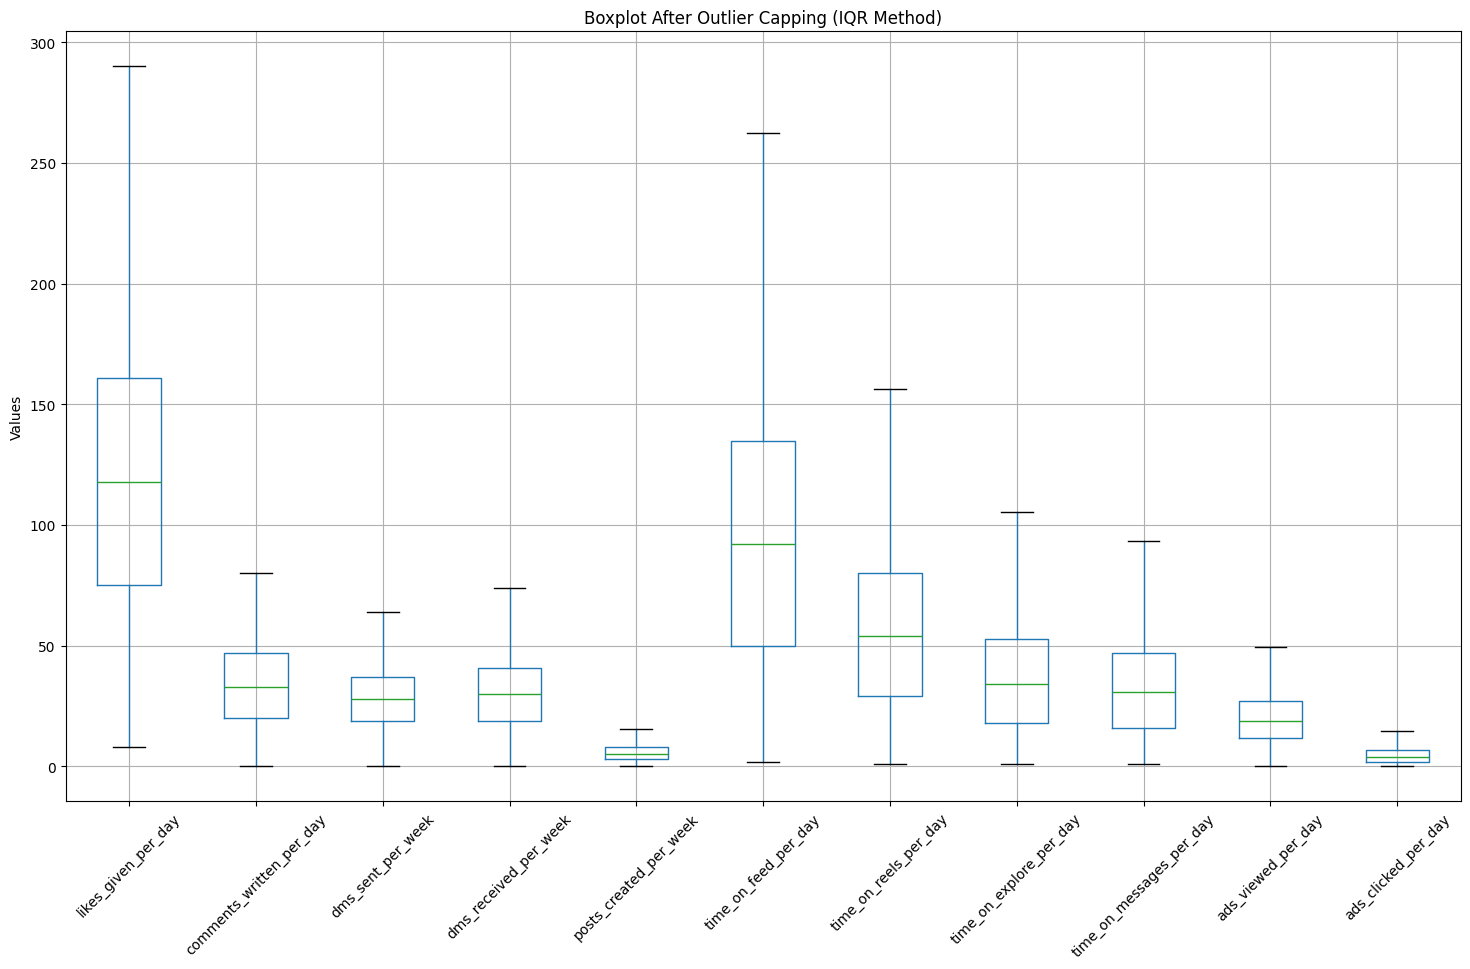

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18,10))
data[cols].boxplot(rot=45)
plt.title("Boxplot After Outlier Capping (IQR Method)")
plt.ylabel("Values")
plt.show()


In [ ]:
for col in cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    upper_limit = Q3 + 1.5 * IQR

    print(col, "values above upper limit:", (data[col] > upper_limit).sum())


likes_given_per_day values above upper limit: 0
comments_written_per_day values above upper limit: 0
dms_sent_per_week values above upper limit: 0
dms_received_per_week values above upper limit: 0
posts_created_per_week values above upper limit: 0
time_on_feed_per_day values above upper limit: 0
time_on_reels_per_day values above upper limit: 0
time_on_explore_per_day values above upper limit: 0
time_on_messages_per_day values above upper limit: 0
ads_viewed_per_day values above upper limit: 0
ads_clicked_per_day values above upper limit: 0


- Outliers were treated using IQR-based capping to limit extreme values while preserving all user records

# **Data Wrangling**

In [ ]:
data = data.copy()

In [ ]:
data.shape

(1547896, 58)

### ***Key Business Metric***

**Engagement Quality Efficiency (EQE)**

Engagement Quality Efficiency (EQE) = Meaningful Engagement ÷ Attention (Time Spent)

In [ ]:
data['ME'] = (
    data['likes_given_per_day'] +
    3 * data['comments_written_per_day'] +
    2 * (data['dms_sent_per_week'] / 7) +
    4 * (data['posts_created_per_week'] / 7)
)

In [ ]:
data['A'] = (
    data['time_on_feed_per_day'] +
    data['time_on_reels_per_day'] +
    data['time_on_explore_per_day'] +
    data['time_on_messages_per_day']
)

In [ ]:
data['EQE'] = data['ME'] / data['A']
data['EQE'] = data['EQE'].replace([float('inf'), -float('inf')], 0).fillna(0)

In [ ]:
data['EQE']

,EQE
0,8.023810
1,1.410084
2,8.404762
3,0.874008
4,1.057823
...,...
1547891,0.812212
1547892,1.139683
1547893,1.077110
1547894,1.150000


In [ ]:
EQE_level=data['EQE_level'] = pd.qcut(data['EQE'], q=3, labels=['Low EQE', 'Medium EQE', 'High EQE'])


In [ ]:
EQE_level

,EQE
0,High EQE
1,High EQE
2,High EQE
3,Low EQE
4,Medium EQE
...,...
1547891,Low EQE
1547892,Medium EQE
1547893,Medium EQE
1547894,Medium EQE


- This helps to  analyze who has high  vs low  engagement.

In [ ]:
data[['ME','A','EQE']].describe()

,ME,A,EQE
count,1.547896e+06,1.547896e+06,1.547896e+06
mean,2.333607e+02,2.209884e+02,1.639865e+00
std,1.106770e+02,1.310632e+02,1.904765e+00
min,1.928571e+01,5.000000e+00,5.692641e-01
25%,1.460000e+02,1.180000e+02,9.667208e-01
50%,2.301429e+02,2.170000e+02,1.089172e+00
75%,3.161429e+02,3.170000e+02,1.301314e+00
max,5.571429e+02,6.180000e+02,1.848571e+01


 **Interaction Health Metrics**

Comment-to-Like Ratio = comments_written_per_day ÷ likes_given_per_day


In [ ]:
data['Comment_to_Like_Ratio'] = data['comments_written_per_day'] / data['likes_given_per_day'].replace(0, 1)


DM Activity Index = (dms_sent_per_week + dms_received_per_week) / 7

In [ ]:
data['DM_Activity_Index'] = (data['dms_sent_per_week'] + data['dms_received_per_week']) / 7


In [ ]:
data[['Comment_to_Like_Ratio', 'DM_Activity_Index']].head()


,Comment_to_Like_Ratio,DM_Activity_Index
0,0.178571,3.428571
1,0.220588,4.000000
2,0.240000,3.571429
3,0.272727,9.000000
4,0.349515,9.428571


**Ads Efficiency**

Ad CTR Proxy = ads_clicked_per_day ÷ ads_viewed_per_day



In [ ]:
data['Ad_CTR_Proxy'] = data['ads_clicked_per_day'] / data['ads_viewed_per_day'].replace(0, 1)


Ad Load Proxy = ads_viewed_per_day ÷ A

In [ ]:
data['Ad_Load_Proxy'] = data['ads_viewed_per_day'] / data['A'].replace(0, 1)

In [ ]:
data[['Ad_CTR_Proxy', 'Ad_Load_Proxy']].head()

,Ad_CTR_Proxy,Ad_Load_Proxy
0,0.250000,0.666667
1,0.090909,0.129412
2,0.000000,0.666667
3,0.090909,0.114583
4,0.250000,0.095238


### ***Deconstruct EQE across key dimensions***

**Demographics**

+ 1. EQE by age



In [ ]:
bins = [0, 18, 25, 35, 50, 100]
labels = ['13-18', '19-25', '26-35', '36-50', '51+']

data['age_group'] = pd.cut(data['age'], bins=bins, labels=labels)


In [ ]:
eqe_by_age=data.groupby('age_group',observed=True)['EQE'].mean().sort_values(ascending=False)
eqe_by_age

,EQE
age_group,
51+,1.983521
36-50,1.673970
26-35,1.462502
19-25,1.375322
13-18,1.302637


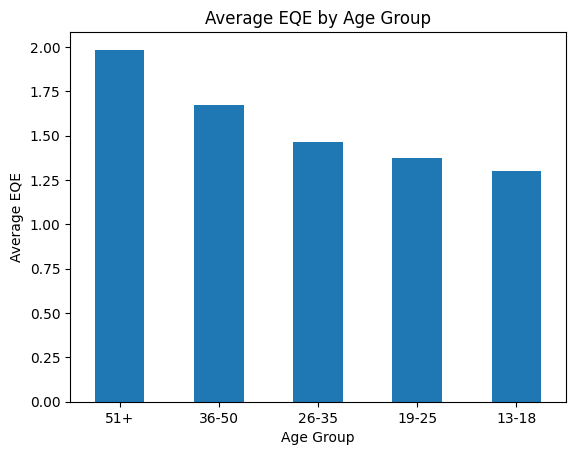

In [ ]:
eqe_by_age.plot(kind='bar')
plt.title("Average EQE by Age Group")
plt.ylabel("Average EQE")
plt.xlabel("Age Group")
plt.xticks(rotation=0)
plt.show()


- *Older (51+) users shows the more meaningful engagement where as younger users(13-18)spend time more passively.*

+ 2. EQE by gender



In [ ]:
data['gender'].value_counts()

,count
gender,
Male,743169
Female,742847
Non-binary,46196
Prefer not to say,15684


In [ ]:
eqe_by_gen=data.groupby('gender')['EQE'].mean().sort_values(ascending=False)
eqe_by_gen

,EQE
gender,
Prefer not to say,1.652077
Female,1.640161
Male,1.639469
Non-binary,1.637321


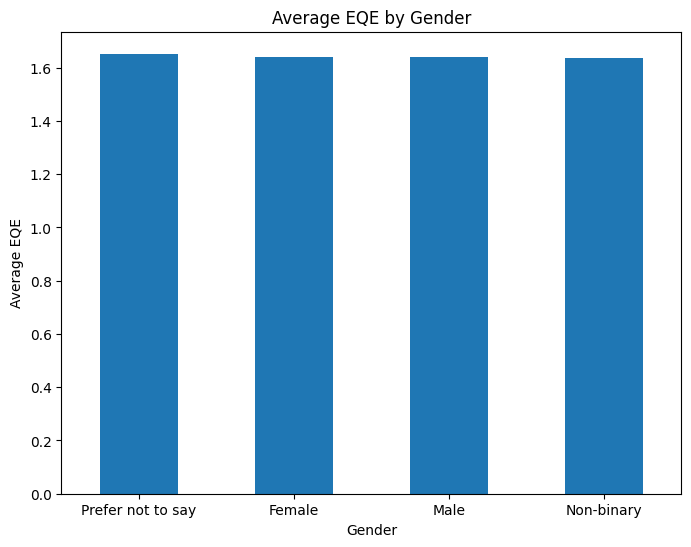

In [ ]:
plt.figure(figsize=(8, 6))
eqe_by_gen.plot(kind='bar')
plt.title("Average EQE by Gender")
plt.ylabel("Average EQE")
plt.xlabel("Gender")
plt.xticks(rotation=0)
plt.show()

- *EQE values are very similar across all gender groups — Prefer not to say (1.65), Female (1.64), Male (1.64), and Non-binary (1.64). so indicating that engagement quality does not  differ by gender.*



- 3.EQE by Area Type

In [ ]:
urban_rural_eqe = data.groupby('urban_rural', observed=True)['EQE'].mean()
urban_rural_eqe


,EQE
urban_rural,
Rural,1.639875
Suburban,1.641562
Urban,1.638935


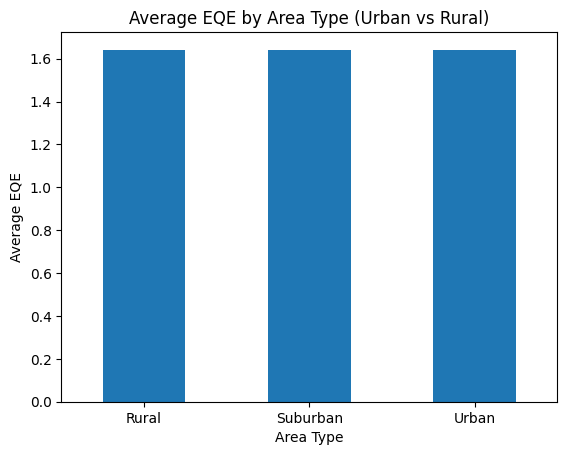

In [ ]:
urban_rural_eqe.plot(kind='bar')
plt.title("Average EQE by Area Type (Urban vs Rural)")
plt.ylabel("Average EQE")
plt.xlabel("Area Type")
plt.xticks(rotation=0)
plt.show()


- *EQE values are nearly the same for rural, suburban, and urban users.*

**Platform Behavior**

- 1.EQE by Sessions Per Day

In [ ]:
sessions_eqe = data.groupby('sessions_per_day')['EQE'].mean().sort_index()



In [ ]:
sessions_eqe.head(5)

,EQE
sessions_per_day,
1,6.511630
2,1.766835
3,1.447130
4,1.297746
5,1.208620


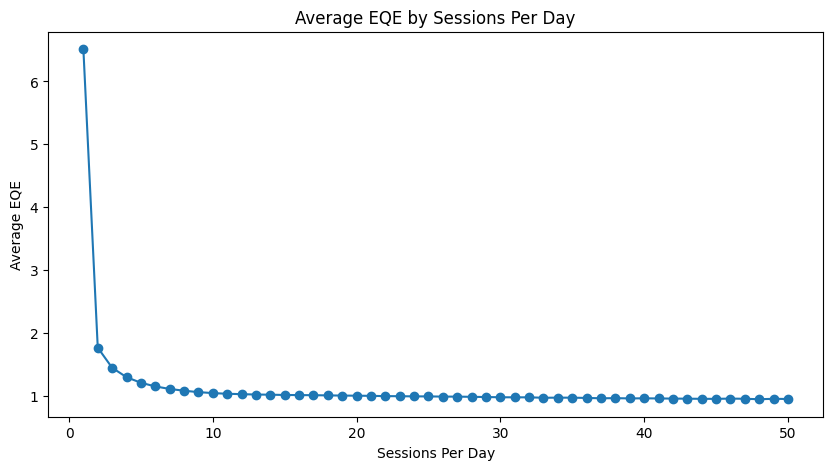

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(sessions_eqe.index, sessions_eqe.values,marker='o')
plt.title("Average EQE by Sessions Per Day")
plt.xlabel("Sessions Per Day")
plt.ylabel("Average EQE")
plt.show()

- *Frequent app visits are linked to lower engagement efficiency, suggesting more passive or habitual usage.*

- 2.EQE by Average Session Length

In [ ]:
data['session_length_group'] = pd.qcut(data['average_session_length_minutes'],5,
    labels=['Very Short', 'Short', 'Medium', 'Long', 'Very Long'])


In [ ]:
session_eqe = data.groupby('session_length_group', observed=True)['EQE'].mean()
session_eqe


,EQE
session_length_group,
Very Short,3.439071
Short,1.226841
Medium,1.190726
Long,1.152597
Very Long,1.139914


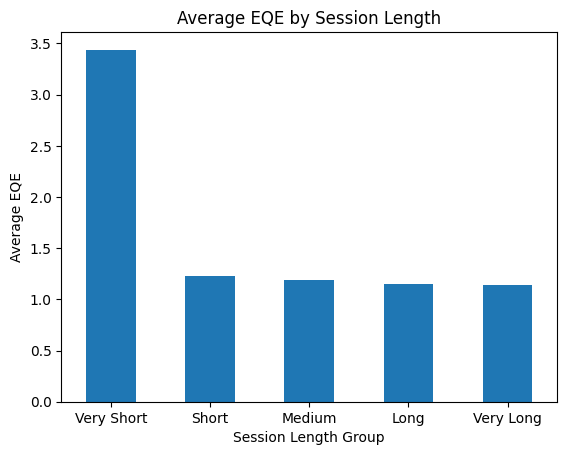

In [ ]:
session_eqe.plot(kind='bar')
plt.title("Average EQE by Session Length")
plt.ylabel("Average EQE")
plt.xlabel("Session Length Group")
plt.xticks(rotation=0)
plt.show()


- *Short sessions are more focused and meaningful, while longer sessions tend to reflect passive browsing.*

- 3.Daily active minutes on Instagram

In [ ]:
data['daily_minutes_group'] = pd.qcut(
    data['daily_active_minutes_instagram'],
    5,
    labels=['Very Low', 'Low', 'Medium', 'High', 'Very High']
)

eqe_by_minutes = data.groupby('daily_minutes_group', observed=True)['EQE'].mean()
eqe_by_minutes


,EQE
daily_minutes_group,
Very Low,3.945571
Low,1.198206
Medium,1.066799
High,1.011846
Very High,0.969047


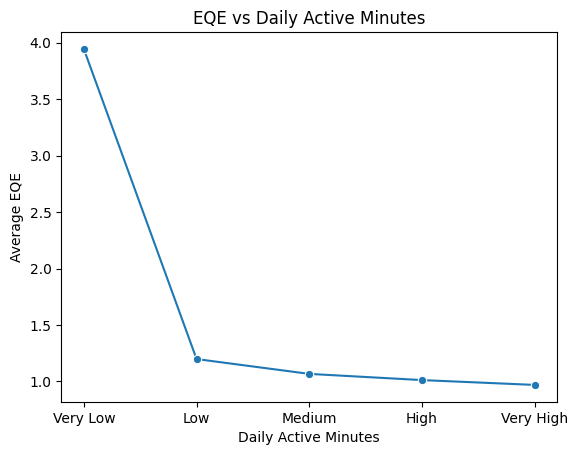

In [ ]:
eqe_by_minutes = data.groupby('daily_minutes_group', observed=True)['EQE'].mean()

sns.lineplot(x=eqe_by_minutes.index, y=eqe_by_minutes.values, marker='o')
plt.title("EQE vs Daily Active Minutes")
plt.xlabel("Daily Active Minutes")
plt.ylabel("Average EQE")
plt.show()


- *EQE is highest for users with very low daily active minutes, and it gradually decreases as daily usage increases. This indicates that users who spend more time on the app tend to engage less meaningfully per minute, suggesting more passive browsing behavior among heavy users.*

- 4.Notification response rate

In [ ]:
data['notif_response_group'] = pd.qcut(
    data['notification_response_rate'],
    5,
    labels=['Very Low', 'Low', 'Medium', 'High', 'Very High']
)

eqe_by_notif = data.groupby('notif_response_group', observed=True)['EQE'].mean()
eqe_by_notif


,EQE
notif_response_group,
Very Low,1.640596
Low,1.636590
Medium,1.643455
High,1.641185
Very High,1.637418


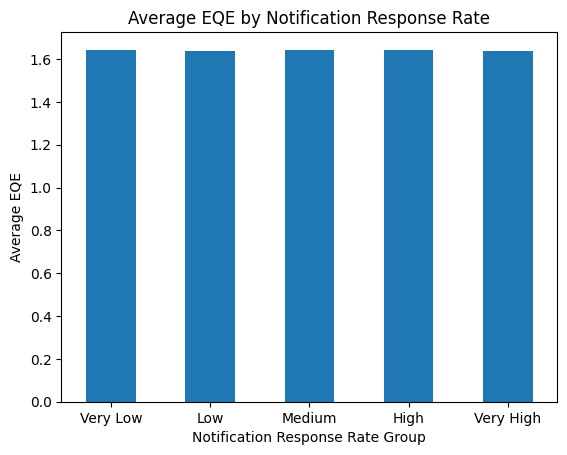

In [ ]:
eqe_by_notif.plot(kind='bar')
plt.title("Average EQE by Notification Response Rate")
plt.ylabel("Average EQE")
plt.xlabel("Notification Response Rate Group")
plt.xticks(rotation=0)
plt.show()


- *EQE remains almost the same across all notification response rate groups, from Very Low to Very High.*

**Content Preferences**

- 1. EQE by Content Type Preference

In [ ]:
content_eqe = data.groupby('content_type_preference', observed=True)['EQE'].mean().sort_values(ascending=False)
content_eqe

,EQE
content_type_preference,
Photos,1.644580
Stories,1.643278
Reels,1.640078
Live,1.638293
Videos,1.637887
Mixed,1.635075


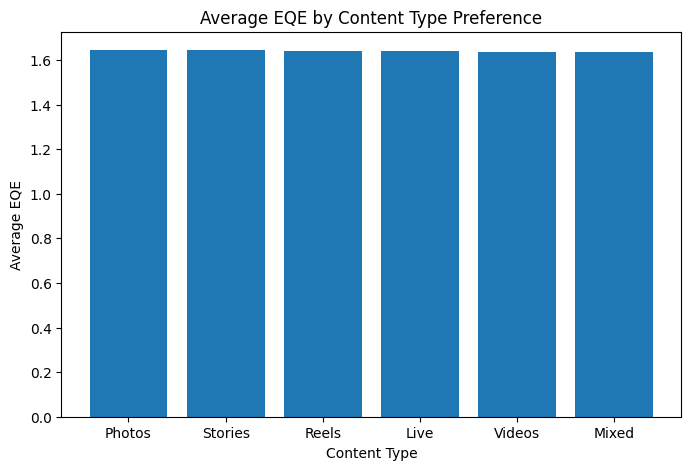

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(content_eqe.index, content_eqe.values)
plt.title("Average EQE by Content Type Preference")
plt.ylabel("Average EQE")
plt.xlabel("Content Type")
plt.show()

- *EQE remains same across all content type*

In [ ]:
theme_eqe = data.groupby('preferred_content_theme', observed=True)['EQE'].mean().sort_values(ascending=False)
theme_eqe

,EQE
preferred_content_theme,
Tech,1.645280
Fitness,1.642313
Art,1.641215
Music,1.641147
Fashion,1.639693
Travel,1.637914
Other,1.635868
Food,1.635466


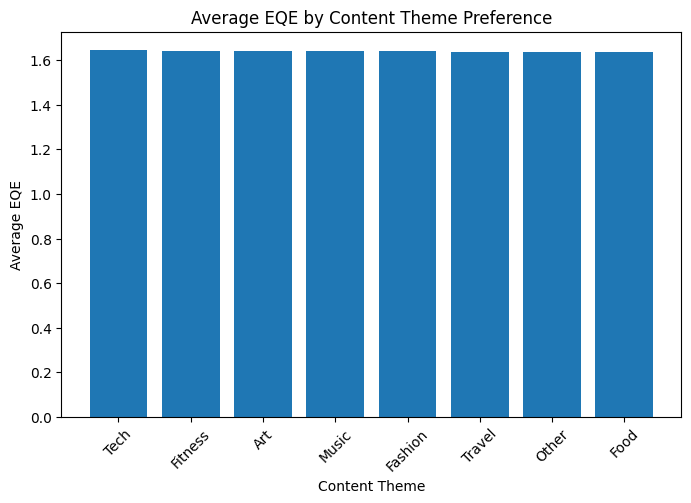

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(theme_eqe.index, theme_eqe.values)
plt.title("Average EQE by Content Theme Preference")
plt.ylabel("Average EQE")
plt.xlabel("Content Theme")
plt.xticks(rotation=45)
plt.show()


- *EQE values are very similar across all content themes,*

**Account & Trust Factors**

- 1.EQE by Privacy Setting Level

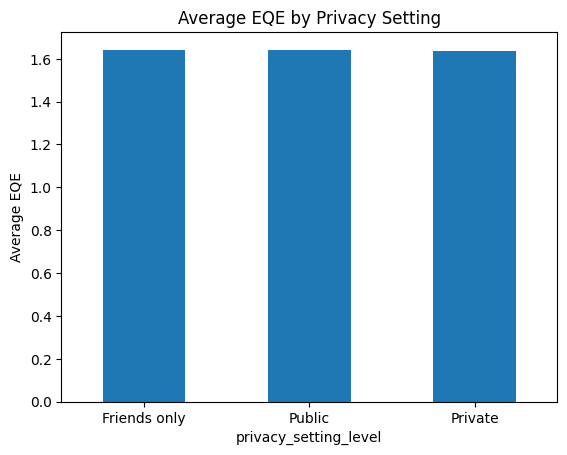

In [ ]:
privacy_eqe = data.groupby('privacy_setting_level', observed=True)['EQE'].mean().sort_values(ascending=False)
privacy_eqe.plot(kind='bar', title="Average EQE by Privacy Setting")
plt.ylabel("Average EQE")
plt.xticks(rotation=0)
plt.show()


- 2.EQE by Subscription Status

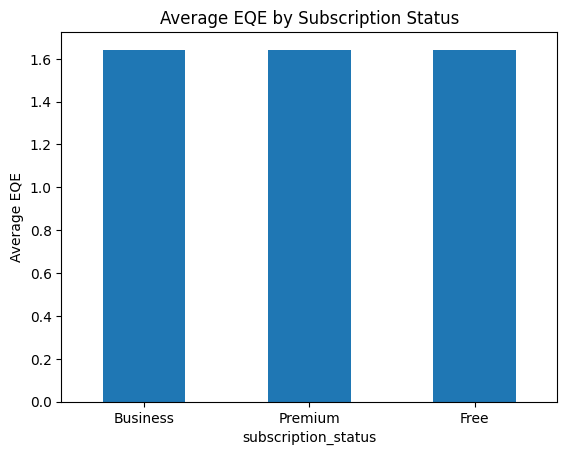

In [ ]:
sub_eqe = data.groupby('subscription_status', observed=True)['EQE'].mean().sort_values(ascending=False)
sub_eqe.plot(kind='bar')
plt.title("Average EQE by Subscription Status")
plt.ylabel("Average EQE")
plt.xticks(rotation=0)
plt.show()


- *EQE remains nearly identical across subscription*

**Identify which combinations drive**

In [ ]:
data['EQE_level']

,EQE_level
0,High EQE
1,High EQE
2,High EQE
3,Low EQE
4,Medium EQE
...,...
1547891,Low EQE
1547892,Medium EQE
1547893,Medium EQE
1547894,Medium EQE


In [ ]:
data['EQE_level'].value_counts().sort_values(ascending=False)

,count
EQE_level,
Medium EQE,515967
Low EQE,515965
High EQE,515964


1. High EQE

In [ ]:
low_session = data['sessions_per_day'].quantile(0.25)
data['Low_Sessions'] = data['sessions_per_day'] <= low_session


data['High_Attention'] = data['A'] >= data['A'].quantile(0.75)


In [ ]:
healthy_users = data[
    (data['EQE_level'] == 'High EQE') &
    (data['Low_Sessions']) &
    (~data['High_Attention'])
]


In [ ]:
healthy_users[['EQE', 'sessions_per_day', 'A']].describe()


,EQE,sessions_per_day,A
count,358967.000000,358967.000000,358967.000000
mean,3.602055,2.374658,57.320169
std,3.248042,1.416544,45.672975
min,1.204407,1.000000,5.000000
25%,1.413445,1.000000,10.000000
50%,1.805714,2.000000,52.000000
75%,5.448980,4.000000,90.000000
max,18.485714,5.000000,235.000000


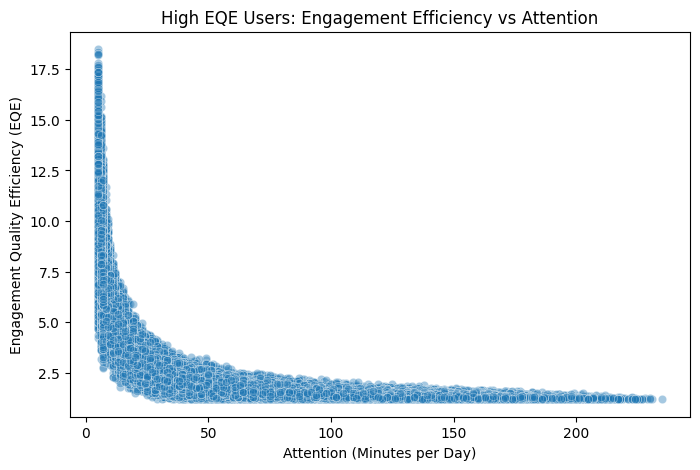

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x=healthy_users['A'],
    y=healthy_users['EQE'],
    alpha=0.4
)
plt.title('High EQE Users: Engagement Efficiency vs Attention')
plt.xlabel('Attention (Minutes per Day)')
plt.ylabel('Engagement Quality Efficiency (EQE)')
plt.show()

- *Users who spend less time tend to engage more meaningfully per minute on average. As time spent increases, engagement efficiency generally declines, indicating more passive usage patterns.*


2. Low EQE

In [ ]:
low_eqe_users = data[data['EQE_level'] == 'Low EQE']


In [ ]:
low_eqe_doom = low_eqe_users[
    low_eqe_users['A'] >= low_eqe_users['A'].quantile(0.75)
]


In [ ]:
low_eqe_doom[['EQE', 'A', 'sessions_per_day']].describe()



,EQE,A,sessions_per_day
count,130093.000000,130093.000000,130093.000000
mean,0.887725,456.924765,20.077491
std,0.068383,44.714644,9.149715
min,0.584687,399.000000,8.000000
25%,0.840481,420.000000,13.000000
50%,0.892510,447.000000,17.000000
75%,0.941558,484.500000,25.000000
max,1.006041,618.000000,50.000000


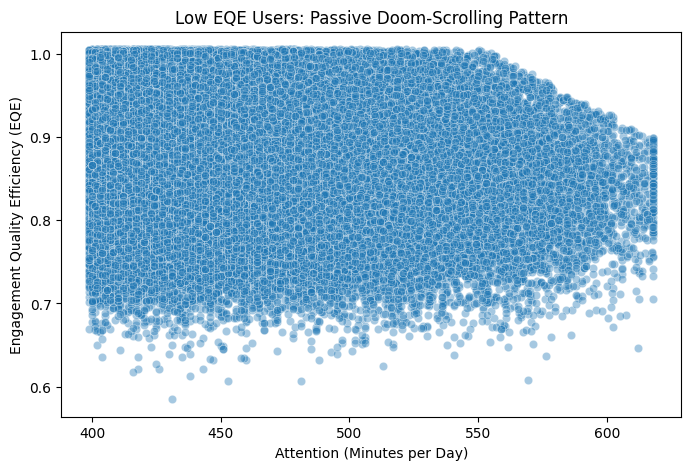

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x=low_eqe_doom['A'],
    y=low_eqe_doom['EQE'],
    alpha=0.4
)
plt.title('Low EQE Users: Passive Doom-Scrolling Pattern')
plt.xlabel('Attention (Minutes per Day)')
plt.ylabel('Engagement Quality Efficiency (EQE)')
plt.show()

- *Low EQE users spend a large amount of time on the platform without a proportional increase in meaningful interactions. This pattern indicates passive, prolonged browsing behavior rather than active engagement.*

3. High EQE vs Low EQE

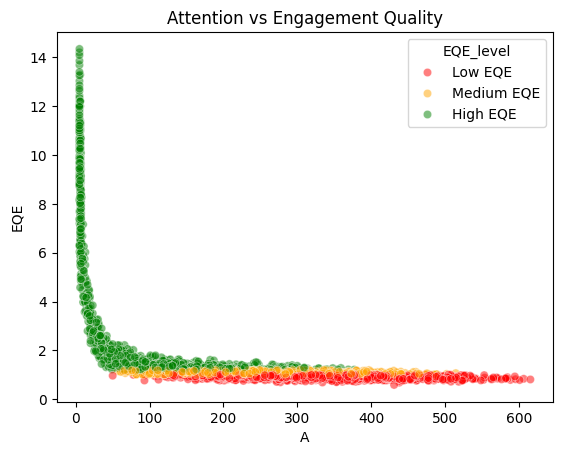

In [ ]:
sns.scatterplot(data=data.sample(5000),
                x='A', y='EQE',
                hue='EQE_level',
                palette={'Low EQE':'red','Medium EQE':'orange','High EQE':'green'},
                alpha=0.5)
plt.title("Attention vs Engagement Quality")
plt.show()


- *Users with high EQE spend less time but interact more meaningfully. Users who spend a lot of time on the app tend to engage less, showing more passive scrolling than active participation.*

4.Dormancy Risk

In [ ]:
data['days_since_last_login'] = (pd.to_datetime('today') - data['last_login_date']).dt.days

data['Dormancy_Risk'] = (
    (data['sessions_per_day'] < 2) &
    (data['notification_response_rate'] < 0.2) &
    (data['days_since_last_login'] > 14)
)


In [ ]:
data['Dormancy_Risk'].value_counts()


,count
Dormancy_Risk,
False,1519174
True,28722


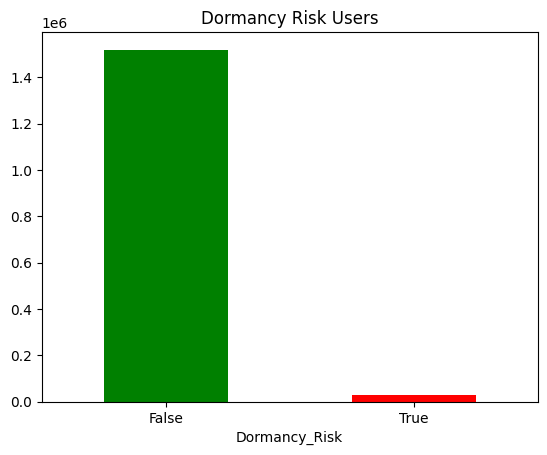

In [ ]:
data['Dormancy_Risk'].value_counts().plot(kind='bar', color=['green','red'])
plt.title("Dormancy Risk Users")
plt.xticks(rotation=0)
plt.show()


- *Most users are active, but about 28,700 users show signs of dormancy risk, meaning they may become inactive soon.*

5.User Interaction Behavior by EQE Level

In [ ]:
interaction_metrics=data.groupby('EQE_level', observed=True)[
    ['likes_given_per_day','comments_written_per_day','dms_sent_per_week','posts_created_per_week']
].mean()


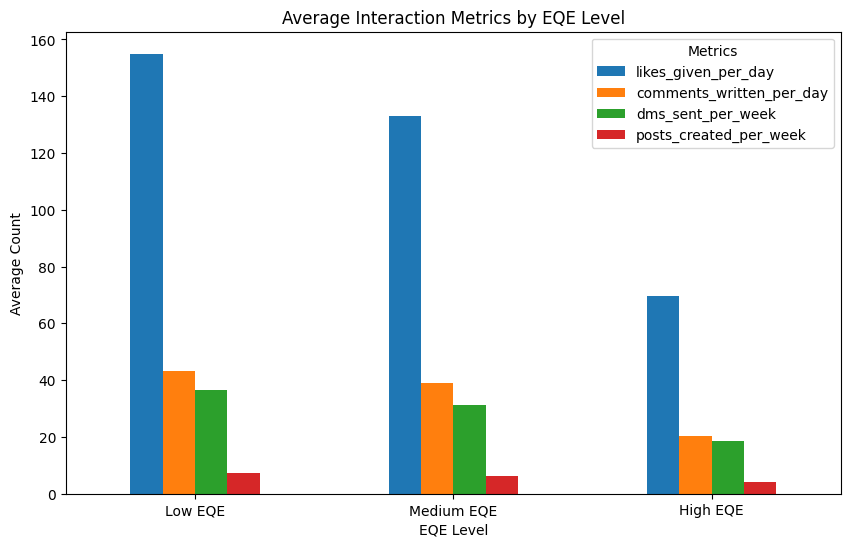

In [ ]:

interaction_metrics.plot(kind='bar', figsize=(10,6))
plt.title("Average Interaction Metrics by EQE Level")
plt.ylabel("Average Count")
plt.xlabel("EQE Level")
plt.xticks(rotation=0)
plt.legend(title="Metrics")
plt.show()

- *Low EQE users perform many actions but spend much more time, resulting in lower engagement efficiency. High EQE users perform fewer actions overall but engage more meaningfully in less time.*

**Lifestyle & Engagement Quality**

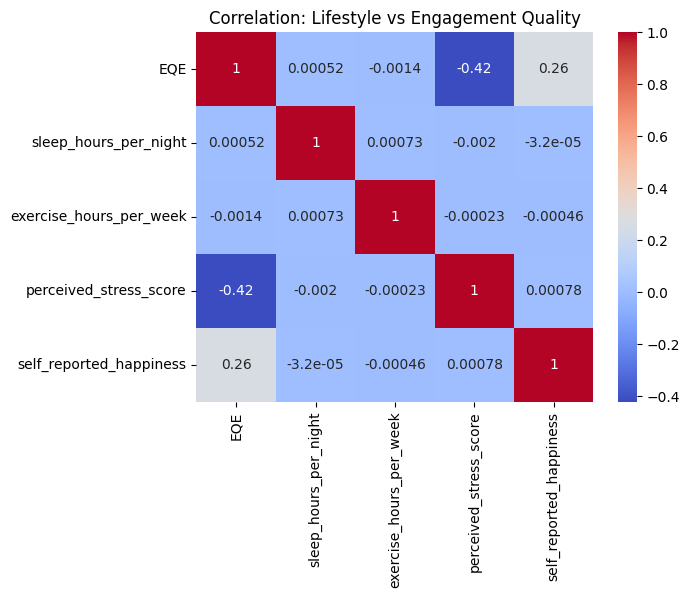

In [ ]:
corr = data[['EQE','sleep_hours_per_night','exercise_hours_per_week','perceived_stress_score','self_reported_happiness']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation: Lifestyle vs Engagement Quality")
plt.show()


- *Users with higher stress levels tend to have lower engagement quality, while users with lower stress show more meaningful and efficient engagement.*

**Supporting Metrics Analysis**

Interaction Health Analysis

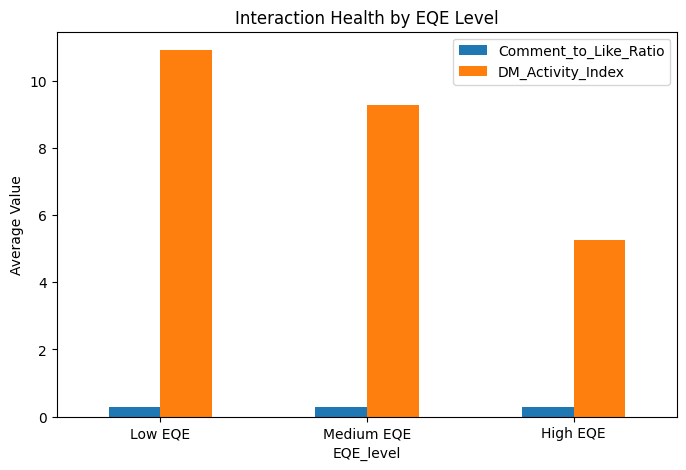

In [ ]:
interaction_health = data.groupby('EQE_level', observed=True)[['Comment_to_Like_Ratio', 'DM_Activity_Index']].mean()

interaction_health.plot(kind='bar', figsize=(8,5))
plt.title("Interaction Health by EQE Level")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.show()


- *High EQE users engage more deeply per interaction, while Low EQE users show high messaging volume but lower engagement efficiency.*

Ads Efficiency Analysis

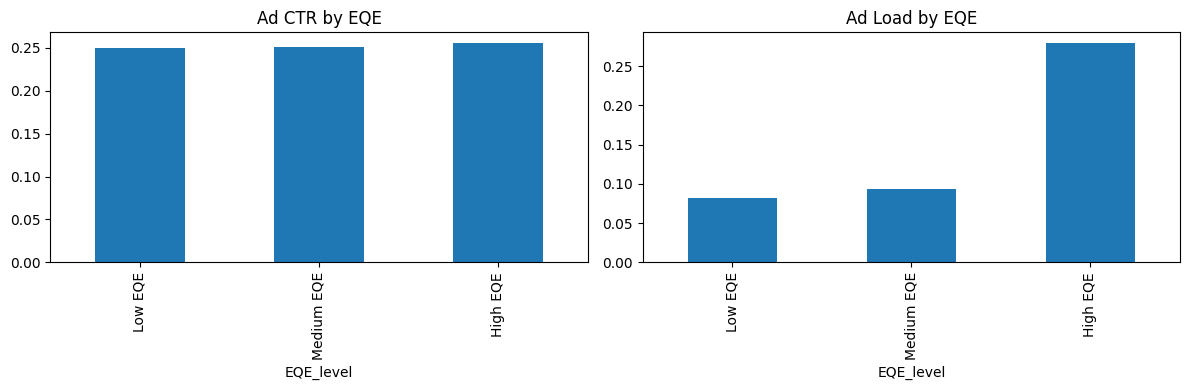

In [ ]:
ads_eff = data.groupby('EQE_level', observed=True)[['Ad_CTR_Proxy', 'Ad_Load_Proxy']].mean()
fig, ax = plt.subplots(1,2, figsize=(12,4))
ads_eff['Ad_CTR_Proxy'].plot(kind='bar', ax=ax[0], title="Ad CTR by EQE")
ads_eff['Ad_Load_Proxy'].plot(kind='bar', ax=ax[1], title="Ad Load by EQE")

plt.tight_layout()
plt.show()


- *Higher engagement quality is associated with better ad responsiveness, but also higher ad exposure, highlighting the need for balanced ad delivery.*

## - **Key Insights**
1.	Engagement quality declines with increased usage intensity.
Users with more sessions per day, longer session lengths, and higher daily active minutes consistently show lower EQE, indicating passive or habitual usage rather than meaningful engagement.
2.	High-quality engagement happens in short, focused sessions.
High EQE users achieve meaningful interactions while spending less time on the platform, showing that intentional usage leads to better engagement efficiency.
3.	Demographics and preferences have limited impact on EQE.
Gender, location (urban/rural), content type, content theme, privacy settings, and subscription status show minimal differences in engagement quality, suggesting behavior matters more than user attributes.
4.	Notifications do not improve engagement quality on their own.
EQE remains almost unchanged across notification response rate groups, indicating that bringing users back via notifications does not guarantee meaningful interaction.
5.	Low EQE users show passive doom-scrolling behavior.
These users spend a large amount of time on Instagram but maintain low engagement efficiency, confirming that more attention does not translate into better engagement.
6.	Lifestyle factors show a limited but important relationship.
Higher stress levels are moderately associated with lower EQE, while happiness is positively associated with engagement quality. Sleep and exercise show weak relationships.
7.	A small segment of users shows dormancy risk.
A minority of users display low session frequency, low notification response, and long gaps since last login, indicating early signs of disengagement.
8.	High EQE users are slightly more valuable for ads.
High EQE users show marginally better ad responsiveness, but they are also exposed to a higher ad load.
9. Engagement quality increases slightly with age. Older users (especially 51+) show higher average EQE compared to younger users, suggesting they engage more intentionally, while younger groups tend to have more passive usage patterns.





## - **Recommendations**
1.	Shift success metrics from time spent to engagement quality.
Product decisions should prioritize meaningful actions (comments, shares, posts, DMs) over increasing total usage time.
2.	Encourage short, intentional sessions.
Design features and UI nudges that promote focused interactions rather than prolonged scrolling.
3.	Rethink notification strategy.
Notifications should be personalized based on past meaningful engagement, not just activity frequency.
4.	Identify and manage passive usage early.
Users with high time spent and low EQE should be monitored as a risk group and guided toward more interactive behaviors.
5.	Support user well-being.
Given the link between stress and lower engagement quality, light well-being prompts or content balance mechanisms may help promote healthier usage.
6.	Target dormancy-risk users with early interventions.
Users showing inactivity signals should receive timely re-engagement efforts to reduce future churn.
7.	Balance ad exposure for high EQE users.
Since high EQE users respond better to ads but see more of them, ad load should be carefully managed to maintain engagement quality.
